In [1]:
# =========================
# Cell 1: Imports
# =========================
import os
import re
import math
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

In [2]:
# =========================
# Cell 2: Config
# =========================
BASE_DIR = Path("/Users/adelshad3/Desktop/Hackathon/Active Learning")

SEQUENCE_FASTA = BASE_DIR / "sequence.fasta"
TRAIN_CSV = BASE_DIR / "train.csv"
TEST_CSV = BASE_DIR / "test.csv"

EMB_DIR = BASE_DIR / "esm_c_embeddings_variants"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

SEED = 42
N_SPLITS = 5
BATCH_SIZE_EMB = 4          # safer on Mac/MPS
BATCH_SIZE_TRAIN = 128
EPOCHS = 250
LR = 1e-4
PATIENCE = 25
WEIGHT_DECAY = 1e-4
DROPOUT = 0.25
HIDDEN_DIM = 512
MAX_QUERY_SIZE = 100

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

Using device: mps


In [3]:
# =========================
# Cell 3: Utilities
# =========================
AA_SET = set("ACDEFGHIKLMNPQRSTVWY")
MUT_RE = re.compile(r"^([A-Z])(\d+)([A-Z])$")

def load_fasta_sequence(fasta_path: Path) -> str:
    lines = fasta_path.read_text().strip().splitlines()
    seq_lines = [line.strip() for line in lines if not line.startswith(">")]
    sequence = "".join(seq_lines)
    if len(sequence) == 0:
        raise ValueError("FASTA sequence is empty.")
    return sequence

sequence_wt = load_fasta_sequence(SEQUENCE_FASTA)
print("WT length:", len(sequence_wt))

def parse_mutant(mutant: str):
    m = MUT_RE.match(mutant)
    if m is None:
        raise ValueError(f"Invalid mutant format: {mutant}")
    wt, pos, mt = m.group(1), int(m.group(2)), m.group(3)
    if wt not in AA_SET or mt not in AA_SET:
        raise ValueError(f"Invalid amino acid in mutant: {mutant}")
    return wt, pos, mt

def get_mutated_sequence(mutant: str, sequence_wt: str) -> str:
    wt, pos, mt = parse_mutant(mutant)

    if pos < 0 or pos >= len(sequence_wt):
        raise ValueError(f"Position out of range in mutant: {mutant}")

    actual_wt = sequence_wt[pos]
    if actual_wt != wt:
        raise ValueError(
            f"Wild-type mismatch for {mutant}: expected {wt}, sequence has {actual_wt} at position {pos}"
        )

    if wt == mt:
        raise ValueError(f"Mutation does not change residue: {mutant}")

    return sequence_wt[:pos] + mt + sequence_wt[pos + 1:]

def safe_spearman(y_true, y_pred):
    rho = spearmanr(y_true, y_pred).statistic
    if rho is None or np.isnan(rho):
        return 0.0
    return float(rho)

WT length: 656


In [7]:
# =========================
# Cell 4: Load data
# =========================
df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)

required_train_cols = {"mutant", "DMS_score"}
required_test_cols = {"mutant"}

if not required_train_cols.issubset(df_train.columns):
    raise ValueError(f"train.csv must contain columns: {required_train_cols}")
if not required_test_cols.issubset(df_test.columns):
    raise ValueError(f"test.csv must contain columns: {required_test_cols}")

df_train = df_train.copy()
df_test = df_test.copy()

df_train["sequence"] = df_train["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test["sequence"] = df_test["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))

print("Train size:", len(df_train))
print("Test size:", len(df_test))

# Basic duplicate safety
if df_train["mutant"].duplicated().any():
    print("Warning: duplicate mutants found in train.csv; keeping first occurrence.")
    df_train = df_train.drop_duplicates(subset=["mutant"], keep="first").reset_index(drop=True)

if df_test["mutant"].duplicated().any():
    print("Warning: duplicate mutants found in test.csv; keeping first occurrence.")
    df_test = df_test.drop_duplicates(subset=["mutant"], keep="first").reset_index(drop=True)

Train size: 1140
Test size: 11324


In [9]:
# =========================
# Cell 5: ESM-C embeddings
# =========================
def gen_emb_from_df(df, out_dir, device, batch_size=4, model_name="esmc_600m"):
    """
    Cache one mean-pooled embedding per mutant at out_dir/{mutant}.pt
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True, parents=True)

    unique_df = df[["mutant", "sequence"]].drop_duplicates().reset_index(drop=True)
    items = list(unique_df.itertuples(index=False, name=None))
    print(f"Unique variants to embed: {len(items)}")

    model = ESMC.from_pretrained(model_name).to(device).eval()

    # Half precision only on CUDA, not on MPS
    if device.type == "cuda":
        model = model.half()

    for start in tqdm(range(0, len(items), batch_size)):
        batch = items[start:start + batch_size]

        for mutant, sequence in batch:
            save_path = out_dir / f"{mutant}.pt"
            if save_path.exists():
                continue

            protein = ESMProtein(sequence=sequence)

            with torch.no_grad():
                protein_tensor = model.encode(protein)
                output = model.logits(
                    protein_tensor,
                    LogitsConfig(sequence=True, return_embeddings=True),
                )

            emb = output.embeddings
            if emb.ndim == 3:
                emb = emb[0]  # [1, L, D] -> [L, D]

            mean_emb = emb.float().mean(dim=0).detach().cpu()
            torch.save(mean_emb, save_path)

all_df = pd.concat(
    [df_train[["mutant", "sequence"]], df_test[["mutant", "sequence"]]],
    ignore_index=True
).drop_duplicates(subset=["mutant"]).reset_index(drop=True)

gen_emb_from_df(all_df, out_dir=EMB_DIR, device=DEVICE, batch_size=BATCH_SIZE_EMB)

Unique variants to embed: 12464


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3116 [00:00<?, ?it/s]

In [10]:
# =========================
# Cell 6: Dataset
# =========================
class DmsESMDataset(Dataset):
    def __init__(self, df, emb_dir, is_train=True):
        self.df = df.reset_index(drop=True).copy()
        self.emb_dir = Path(emb_dir)
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mutant = row["mutant"]
        emb = torch.load(self.emb_dir / f"{mutant}.pt", map_location="cpu").float()

        if self.is_train:
            y = torch.tensor(float(row["DMS_score"]), dtype=torch.float32)
            return emb, y, mutant
        else:
            return emb, torch.tensor(0.0, dtype=torch.float32), mutant

def infer_input_dim(emb_dir, mutant_name):
    emb = torch.load(Path(emb_dir) / f"{mutant_name}.pt", map_location="cpu")
    return int(emb.shape[0])

INPUT_DIM = infer_input_dim(EMB_DIR, df_train.iloc[0]["mutant"])
print("Detected embedding dimension:", INPUT_DIM)

Detected embedding dimension: 1152


In [13]:
# =========================
# Cell 7: Model
# =========================
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout_p=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [15]:
# =========================
# Cell 8: Train / evaluate helpers
# =========================
def make_loader(dataset, batch_size, shuffle):
    # Conservative defaults for Jupyter + Mac
    pin_memory = (DEVICE.type == "cuda")
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=pin_memory
    )

def train_one_fold(model, train_ds, val_ds, device, epochs=250, batch_size=128,
                   lr=1e-4, patience=25, weight_decay=1e-4):
    train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=6
    )

    best_state = None
    best_val_spearman = -np.inf
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_spearman": [],
        "val_spearman": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_preds, train_targets = [], [], []

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_preds.append(preds.detach().cpu().numpy())
            train_targets.append(yb.detach().cpu().numpy())

        train_preds = np.concatenate(train_preds)
        train_targets = np.concatenate(train_targets)
        train_spear = safe_spearman(train_targets, train_preds)

        model.eval()
        val_losses, val_preds, val_targets = [], [], []

        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb)
                loss = criterion(preds, yb)

                val_losses.append(loss.item())
                val_preds.append(preds.detach().cpu().numpy())
                val_targets.append(yb.detach().cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        val_spear = safe_spearman(val_targets, val_preds)

        mean_train_loss = float(np.mean(train_losses))
        mean_val_loss = float(np.mean(val_losses))

        history["train_loss"].append(mean_train_loss)
        history["val_loss"].append(mean_val_loss)
        history["train_spearman"].append(train_spear)
        history["val_spearman"].append(val_spear)

        scheduler.step(val_spear)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {mean_train_loss:.4f} | Train Spearman {train_spear:.4f} | "
            f"Val Loss {mean_val_loss:.4f} | Val Spearman {val_spear:.4f} | "
            f"LR {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_spear > best_val_spearman:
            best_val_spearman = val_spear
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return best_state, best_val_spearman, history

def predict_dataset(model, dataset, device, batch_size=128):
    loader = make_loader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    preds, mutants = [], []
    with torch.no_grad():
        for xb, _, batch_mutants in loader:
            xb = xb.to(device)
            out = model(xb).detach().cpu().numpy()
            preds.extend(out.tolist())
            mutants.extend(list(batch_mutants))

    return pd.DataFrame({"mutant": mutants, "prediction": preds})

In [17]:
# =========================
# Cell 9: 5-fold CV + ensemble predictions on test
# =========================
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_histories = []
fold_scores = []
fold_states = []

oof_preds = np.zeros(len(df_train), dtype=float)

test_ds = DmsESMDataset(df_test, EMB_DIR, is_train=False)
test_pred_matrix = []

indices = np.arange(len(df_train))

for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
    print(f"\n========== Fold {fold}/{N_SPLITS} ==========")

    df_tr = df_train.iloc[train_idx].reset_index(drop=True)
    df_va = df_train.iloc[val_idx].reset_index(drop=True)

    train_ds = DmsESMDataset(df_tr, EMB_DIR, is_train=True)
    val_ds = DmsESMDataset(df_va, EMB_DIR, is_train=True)

    model = MLPRegressor(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        dropout_p=DROPOUT
    ).to(DEVICE)

    best_state, best_val_spear, history = train_one_fold(
        model=model,
        train_ds=train_ds,
        val_ds=val_ds,
        device=DEVICE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE_TRAIN,
        lr=LR,
        patience=PATIENCE,
        weight_decay=WEIGHT_DECAY
    )

    model.load_state_dict(best_state)
    fold_states.append(best_state)
    fold_histories.append(history)
    fold_scores.append(best_val_spear)

    # OOF predictions
    val_pred_df = predict_dataset(model, val_ds, device=DEVICE, batch_size=BATCH_SIZE_TRAIN)
    mutant_to_pred = dict(zip(val_pred_df["mutant"], val_pred_df["prediction"]))
    oof_preds[val_idx] = [mutant_to_pred[m] for m in df_train.iloc[val_idx]["mutant"]]

    # Test predictions
    test_pred_df = predict_dataset(model, test_ds, device=DEVICE, batch_size=BATCH_SIZE_TRAIN)
    test_pred_matrix.append(test_pred_df["prediction"].values)

    print(f"Fold {fold} best val Spearman: {best_val_spear:.4f}")

cv_spearman = safe_spearman(df_train["DMS_score"].values, oof_preds)
print("\nFold scores:", np.round(fold_scores, 4))
print("OOF Spearman:", round(cv_spearman, 4))


========== Fold 1/5 ==========
Epoch 001 | Train Loss 0.1296 | Train Spearman -0.0565 | Val Loss 0.0568 | Val Spearman -0.0865 | LR 1.00e-04
Epoch 002 | Train Loss 0.0845 | Train Spearman 0.0122 | Val Loss 0.0516 | Val Spearman 0.0102 | LR 1.00e-04
Epoch 003 | Train Loss 0.0733 | Train Spearman -0.0396 | Val Loss 0.0562 | Val Spearman 0.1360 | LR 1.00e-04
Epoch 004 | Train Loss 0.0660 | Train Spearman 0.0242 | Val Loss 0.0697 | Val Spearman 0.1725 | LR 1.00e-04
Epoch 005 | Train Loss 0.0637 | Train Spearman -0.0108 | Val Loss 0.0591 | Val Spearman 0.3028 | LR 1.00e-04
Epoch 006 | Train Loss 0.0589 | Train Spearman -0.0039 | Val Loss 0.0497 | Val Spearman 0.3235 | LR 1.00e-04
Epoch 007 | Train Loss 0.0528 | Train Spearman 0.0108 | Val Loss 0.0488 | Val Spearman 0.2967 | LR 1.00e-04
Epoch 008 | Train Loss 0.0466 | Train Spearman 0.0138 | Val Loss 0.0528 | Val Spearman 0.3242 | LR 1.00e-04
Epoch 009 | Train Loss 0.0493 | Train Spearman 0.0202 | Val Loss 0.0498 | Val Spearman 0.3266 | LR 

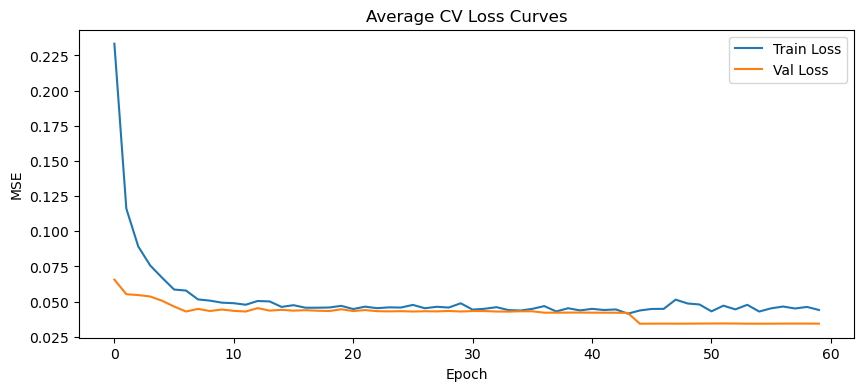

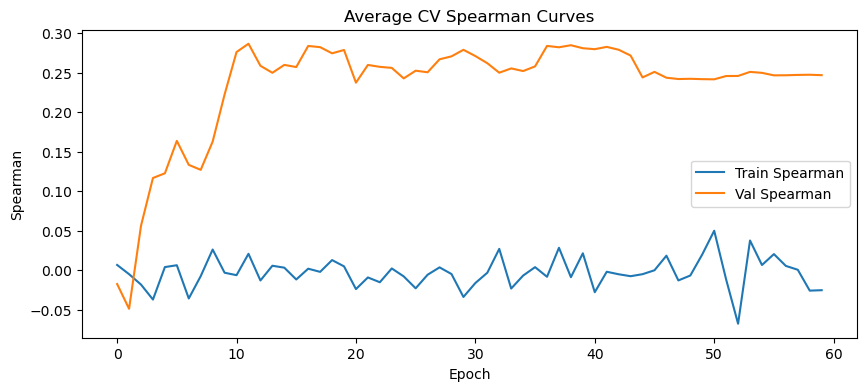

In [18]:
# =========================
# Cell 10: Plot CV curves
# =========================
def average_histories(histories, key):
    max_len = max(len(h[key]) for h in histories)
    arr = np.full((len(histories), max_len), np.nan, dtype=float)
    for i, h in enumerate(histories):
        arr[i, :len(h[key])] = h[key]
    return np.nanmean(arr, axis=0)

avg_train_loss = average_histories(fold_histories, "train_loss")
avg_val_loss = average_histories(fold_histories, "val_loss")
avg_train_spear = average_histories(fold_histories, "train_spearman")
avg_val_spear = average_histories(fold_histories, "val_spearman")

plt.figure(figsize=(10, 4))
plt.plot(avg_train_loss, label="Train Loss")
plt.plot(avg_val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Average CV Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(avg_train_spear, label="Train Spearman")
plt.plot(avg_val_spear, label="Val Spearman")
plt.xlabel("Epoch")
plt.ylabel("Spearman")
plt.title("Average CV Spearman Curves")
plt.legend()
plt.show()

In [23]:
# =========================
# Cell 11: Final predictions.csv and top10.txt
# =========================
test_pred_matrix = np.vstack(test_pred_matrix)   # [n_folds, n_test]
test_pred_mean = test_pred_matrix.mean(axis=0)
test_pred_std = test_pred_matrix.std(axis=0)

df_pred = df_test[["mutant"]].copy()
df_pred["DMS_score"] = test_pred_mean
df_pred["uncertainty"] = test_pred_std

# predictions.csv for leaderboard
predictions_path = OUTPUT_DIR / "predictions.csv"
df_pred[["mutant", "DMS_score"]].to_csv(predictions_path, index=False)

# top10.txt
top10 = (
    df_pred.sort_values("DMS_score", ascending=False)
    .head(10)[["mutant"]]
)
top10_path = OUTPUT_DIR / "top10.txt"
top10.to_csv(top10_path, index=False, header=False)

print("Saved:", predictions_path)
print("Saved:", top10_path)

display(df_pred.sort_values("DMS_score", ascending=False).head(20))

Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/predictions.csv
Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/top10.txt


,mutant,DMS_score,uncertainty
237,C13I,0.229768,0.003381
246,C13S,0.229716,0.003420
7157,L436R,0.229710,0.003271
10842,C630R,0.229709,0.003401
4685,V282R,0.229698,0.003390
10834,C630G,0.229678,0.003360
3397,K198T,0.229661,0.003233
243,C13Y,0.229655,0.003518
3391,K198A,0.229653,0.003233
242,C13T,0.229646,0.003301


In [25]:
# =========================
# Cell 12: Active learning query strategy
# =========================
def enrich_candidate_features(df_candidates):
    """
    Add parsed mutation info for diversity-aware selection.
    """
    df = df_candidates.copy()
    parsed = df["mutant"].apply(parse_mutant)
    df["wt"] = parsed.apply(lambda x: x[0])
    df["position"] = parsed.apply(lambda x: x[1])
    df["mt"] = parsed.apply(lambda x: x[2])
    return df

def build_query_set(
    df_candidates,
    df_labeled,
    query_size=100,
    exploit_frac=0.4,
    uncertain_frac=0.4,
    diverse_frac=0.2
):
    """
    Mix of:
      - exploit: highest predicted fitness
      - uncertain: highest ensemble std
      - diverse: spread over positions / mutation types
    """
    df_candidates = enrich_candidate_features(df_candidates)
    labeled_set = set(df_labeled["mutant"].tolist())

    # Exclude already labeled points
    pool = df_candidates[~df_candidates["mutant"].isin(labeled_set)].copy()
    pool = pool.drop_duplicates(subset=["mutant"]).reset_index(drop=True)

    n_exploit = int(query_size * exploit_frac)
    n_uncertain = int(query_size * uncertain_frac)
    n_diverse = query_size - n_exploit - n_uncertain

    selected = []

    # 1) Exploit: high predicted score
    exploit = pool.sort_values(["DMS_score", "uncertainty"], ascending=[False, False])
    for mut in exploit["mutant"]:
        if len(selected) >= n_exploit:
            break
        selected.append(mut)

    # 2) Uncertainty: high disagreement across folds
    uncertain = pool.sort_values(["uncertainty", "DMS_score"], ascending=[False, False])
    for mut in uncertain["mutant"]:
        if len(selected) >= n_exploit + n_uncertain:
            break
        if mut not in selected:
            selected.append(mut)

    # 3) Diversity: prefer new positions and mutation letters
    diverse_pool = pool[~pool["mutant"].isin(selected)].copy()
    diverse_pool = diverse_pool.sort_values(
        ["uncertainty", "DMS_score"], ascending=[False, False]
    ).reset_index(drop=True)

    used_positions = set(pool[pool["mutant"].isin(selected)]["position"].tolist())
    used_mts = set(pool[pool["mutant"].isin(selected)]["mt"].tolist())

    diversity_selected = []

    # First pass: maximize new positions and new mutant letters
    for _, row in diverse_pool.iterrows():
        if len(diversity_selected) >= n_diverse:
            break
        pos_new = row["position"] not in used_positions
        mt_new = row["mt"] not in used_mts
        if pos_new or mt_new:
            diversity_selected.append(row["mutant"])
            used_positions.add(row["position"])
            used_mts.add(row["mt"])

    # Second pass: fill any remaining slots
    if len(diversity_selected) < n_diverse:
        for mut in diverse_pool["mutant"]:
            if len(diversity_selected) >= n_diverse:
                break
            if mut not in diversity_selected:
                diversity_selected.append(mut)

    selected.extend(diversity_selected)

    # Final safety checks
    selected = selected[:query_size]
    assert len(selected) == len(set(selected)), "Duplicate mutants in query set"
    assert len(selected) <= query_size, "Too many query mutants"
    assert all(m not in labeled_set for m in selected), "Query includes labeled mutants"

    return selected

query_mutants = build_query_set(
    df_candidates=df_pred[["mutant", "DMS_score", "uncertainty"]],
    df_labeled=df_train,
    query_size=MAX_QUERY_SIZE
)

query_path = OUTPUT_DIR / "query.txt"
with open(query_path, "w") as f:
    for mut in query_mutants:
        f.write(mut + "\n")

print("Saved:", query_path)
print("Number of queries:", len(query_mutants))
print(query_mutants[:20])

Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/query.txt
Number of queries: 100
['C13I', 'C13S', 'L436R', 'C630R', 'V282R', 'C630G', 'K198T', 'C13Y', 'K198A', 'C13T', 'M245A', 'Q526A', 'R5N', 'C13N', 'C31A', 'C13F', 'V435R', 'M153L', 'C630E', 'K198S']


## Helper functions for active learning

In [ ]:
def add_sequence_column(df, sequence_wt):
    df = df.copy()
    df["sequence"] = df["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))
    return df

def merge_new_query_results(df_train, new_results_path, sequence_wt):
    """
    new_results_path must contain columns: mutant, DMS_score
    """
    new_df = pd.read_csv(new_results_path)

    if not {"mutant", "DMS_score"}.issubset(new_df.columns):
        raise ValueError(f"{new_results_path} must contain columns: mutant, DMS_score")

    new_df = add_sequence_column(new_df, sequence_wt)

    merged = pd.concat(
        [
            df_train[["mutant", "DMS_score", "sequence"]],
            new_df[["mutant", "DMS_score", "sequence"]],
        ],
        ignore_index=True,
    )

    merged = merged.drop_duplicates(subset=["mutant"], keep="last").reset_index(drop=True)
    return merged, new_df

In [ ]:
def train_cv_and_predict(df_train, df_test, emb_dir, device,
                         n_splits=5, hidden_dim=512, dropout=0.25,
                         epochs=250, batch_size=128, lr=1e-4,
                         patience=25, weight_decay=1e-4):
    """
    Retrains 5-fold CV models on updated train set.
    Returns:
      df_pred: test predictions with mean and std across folds
      fold_scores: validation spearman of each fold
      oof_spearman: overall out-of-fold spearman on current train set
      fold_histories: training histories
      fold_states: checkpoints for each fold
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    indices = np.arange(len(df_train))

    test_ds = DmsESMDataset(df_test, emb_dir, is_train=False)

    fold_scores = []
    fold_histories = []
    fold_states = []
    test_pred_matrix = []
    oof_preds = np.zeros(len(df_train), dtype=float)

    for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        print(f"\n========== Fold {fold}/{n_splits} ==========")

        df_tr = df_train.iloc[train_idx].reset_index(drop=True)
        df_va = df_train.iloc[val_idx].reset_index(drop=True)

        train_ds = DmsESMDataset(df_tr, emb_dir, is_train=True)
        val_ds = DmsESMDataset(df_va, emb_dir, is_train=True)

        model = MLPRegressor(
            input_dim=INPUT_DIM,
            hidden_dim=hidden_dim,
            dropout_p=dropout
        ).to(device)

        best_state, best_val_spear, history = train_one_fold(
            model=model,
            train_ds=train_ds,
            val_ds=val_ds,
            device=device,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            patience=patience,
            weight_decay=weight_decay
        )

        model.load_state_dict(best_state)

        fold_scores.append(best_val_spear)
        fold_histories.append(history)
        fold_states.append(best_state)

        # OOF predictions
        val_pred_df = predict_dataset(model, val_ds, device=device, batch_size=batch_size)
        mutant_to_pred = dict(zip(val_pred_df["mutant"], val_pred_df["prediction"]))
        oof_preds[val_idx] = [mutant_to_pred[m] for m in df_train.iloc[val_idx]["mutant"]]

        # Test predictions
        test_pred_df = predict_dataset(model, test_ds, device=device, batch_size=batch_size)
        test_pred_matrix.append(test_pred_df["prediction"].values)

        print(f"Fold {fold} val Spearman: {best_val_spear:.4f}")

    oof_spearman = safe_spearman(df_train["DMS_score"].values, oof_preds)

    test_pred_matrix = np.vstack(test_pred_matrix)
    test_pred_mean = test_pred_matrix.mean(axis=0)
    test_pred_std = test_pred_matrix.std(axis=0)

    df_pred = df_test[["mutant"]].copy()
    df_pred["DMS_score"] = test_pred_mean
    df_pred["uncertainty"] = test_pred_std

    return df_pred, fold_scores, oof_spearman, fold_histories, fold_states

In [ ]:
def save_query_file(query_mutants, out_path):
    with open(out_path, "w") as f:
        for m in query_mutants:
            f.write(m + "\n")
    print(f"Saved query file: {out_path}")
    print(f"Number of mutants: {len(query_mutants)}")

In [ ]:
def save_final_outputs(df_pred, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    predictions_path = output_dir / "predictions.csv"
    top10_path = output_dir / "top10.txt"

    df_pred[["mutant", "DMS_score"]].to_csv(predictions_path, index=False)

    top10 = df_pred.sort_values("DMS_score", ascending=False).head(10)[["mutant"]]
    top10.to_csv(top10_path, index=False, header=False)

    print("Saved:", predictions_path)
    print("Saved:", top10_path)

    return predictions_path, top10_path

# After receiving the 1st query results

In [ ]:
ROUND1_RESULTS = BASE_DIR / "round1_query_results.csv"

In [ ]:
df_train, round1_new = merge_new_query_results(df_train, ROUND1_RESULTS, sequence_wt)

print("New round 1 queried points:", len(round1_new))
print("Updated train size after round 1:", len(df_train))
display(round1_new.head())

In [ ]:
gen_emb_from_df(
    round1_new[["mutant", "sequence"]],
    out_dir=EMB_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE_EMB
)

In [ ]:
df_pred_round1, fold_scores_r1, oof_spearman_r1, histories_r1, states_r1 = train_cv_and_predict(
    df_train=df_train,
    df_test=df_test,
    emb_dir=EMB_DIR,
    device=DEVICE,
    n_splits=N_SPLITS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_TRAIN,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY
)

print("Round 1 fold Spearman scores:", np.round(fold_scores_r1, 4))
print("Round 1 OOF Spearman:", round(oof_spearman_r1, 4))
display(df_pred_round1.sort_values("DMS_score", ascending=False).head(20))

In [ ]:
query_round2 = build_query_set(
    df_candidates=df_pred_round1[["mutant", "DMS_score", "uncertainty"]],
    df_labeled=df_train,
    query_size=100,
    exploit_frac=0.20,
    uncertain_frac=0.50,
    diverse_frac=0.30
)

save_query_file(query_round2, OUTPUT_DIR / "query_round2.txt")

# After receiving the second query results

In [ ]:
ROUND2_RESULTS = BASE_DIR / "round2_query_results.csv"

In [ ]:
df_train, round2_new = merge_new_query_results(df_train, ROUND2_RESULTS, sequence_wt)

print("New round 2 queried points:", len(round2_new))
print("Updated train size after round 2:", len(df_train))
display(round2_new.head())

In [ ]:
gen_emb_from_df(
    round2_new[["mutant", "sequence"]],
    out_dir=EMB_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE_EMB
)

In [ ]:
df_pred_round2, fold_scores_r2, oof_spearman_r2, histories_r2, states_r2 = train_cv_and_predict(
    df_train=df_train,
    df_test=df_test,
    emb_dir=EMB_DIR,
    device=DEVICE,
    n_splits=N_SPLITS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_TRAIN,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY
)

print("Round 2 fold Spearman scores:", np.round(fold_scores_r2, 4))
print("Round 2 OOF Spearman:", round(oof_spearman_r2, 4))
display(df_pred_round2.sort_values("DMS_score", ascending=False).head(20))

In [ ]:
query_round3 = build_query_set(
    df_candidates=df_pred_round2[["mutant", "DMS_score", "uncertainty"]],
    df_labeled=df_train,
    query_size=100,
    exploit_frac=0.35,
    uncertain_frac=0.35,
    diverse_frac=0.30
)

save_query_file(query_round3, OUTPUT_DIR / "query_round3.txt")

# After receiving the 3rd query results

In [ ]:
ROUND3_RESULTS = BASE_DIR / "round3_query_results.csv"

In [ ]:
df_train, round3_new = merge_new_query_results(df_train, ROUND3_RESULTS, sequence_wt)

print("New round 3 queried points:", len(round3_new))
print("Updated train size after round 3:", len(df_train))
display(round3_new.head())

In [ ]:
gen_emb_from_df(
    round3_new[["mutant", "sequence"]],
    out_dir=EMB_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE_EMB
)

In [ ]:
df_pred_final, fold_scores_final, oof_spearman_final, histories_final, states_final = train_cv_and_predict(
    df_train=df_train,
    df_test=df_test,
    emb_dir=EMB_DIR,
    device=DEVICE,
    n_splits=N_SPLITS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_TRAIN,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY
)

print("Final fold Spearman scores:", np.round(fold_scores_final, 4))
print("Final OOF Spearman:", round(oof_spearman_final, 4))
display(df_pred_final.sort_values("DMS_score", ascending=False).head(20))

In [ ]:
predictions_path, top10_path = save_final_outputs(df_pred_final, OUTPUT_DIR)

top10_df = df_pred_final.sort_values("DMS_score", ascending=False).head(10)
display(top10_df)